Maciej Szukało 155327
Filip Kempa 155909

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import *

# wczytanie danych z pliku
df = pd.read_csv('Nuclear waste management.csv', index_col=0)
kryteria = ['C1', 'C2', 'C3', 'C4']
warianty = list(df.index)

# pary referencyjne z zadania 2
preferencje = [
    (22, 3), 
    (8, 7),
    (21, 10),
    (14, 25),
    (13, 18) 
]

# zbieranie unikalnych wartosci do wykresow i zmiennych
unikalne_wartosci = {}
for k in kryteria:
    unikalne_wartosci[k] = np.sort(df[k].unique())
    
print("Dane wczytane i gotowe.")

Dane wczytane i gotowe.


Status: Optimal
Epsilon wynosi: 0.2

Ranking z zadania 3:
    Wariant  Uzytecznosc
1        14          0.9
2        13          0.9
3        26          0.8
4        24          0.8
5        23          0.8
6        21          0.8
7        20          0.8
8        15          0.8
9         1          0.8
10       27          0.8
11        4          0.8
12       18          0.7
13       25          0.7
14        9          0.7
15        8          0.7
16       17          0.7
17       22          0.6
18       19          0.6
19       16          0.6
20        7          0.5
21        2          0.5
22       10          0.5
23       11          0.4
24        6          0.4
25        5          0.4
26       12          0.4
27        3          0.4


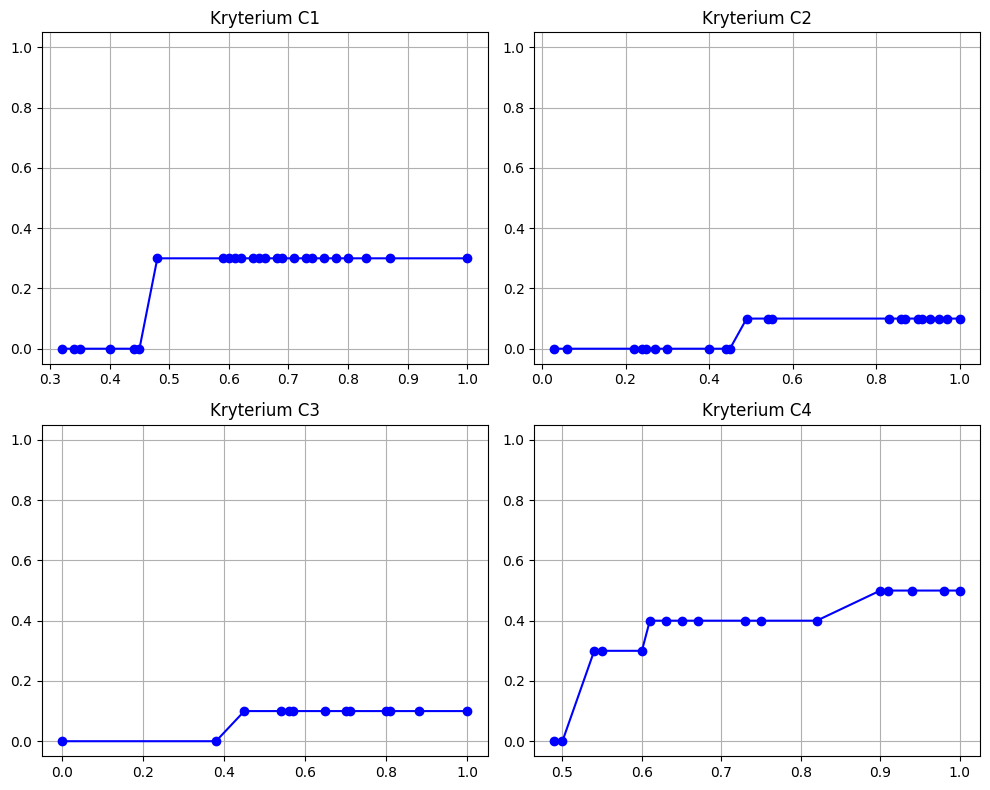

In [7]:
model_uta = LpProblem("UTA_podstawowe", LpMaximize)
eps = LpVariable("epsilon", lowBound=0)

# tworzenie zmiennych decyzyjnych w petli
zmienne_u = {}
for k in kryteria:
    zmienne_u[k] = {}
    for wartosc in unikalne_wartosci[k]:
        nazwa = "U_" + str(k) + "_" + str(wartosc).replace(".", "_")
        zmienne_u[k][wartosc] = LpVariable(nazwa, lowBound=0)

# dodawanie ograniczen
for k in kryteria:
    wartosci = unikalne_wartosci[k]
    # najgorsza wartosc to 0
    model_uta += zmienne_u[k][wartosci[0]] == 0
    # wymog z zadania - min waga to 0.1
    model_uta += zmienne_u[k][wartosci[-1]] >= 0.1
    
    # monotonicznosc
    for i in range(len(wartosci) - 1):
        model_uta += zmienne_u[k][wartosci[i]] <= zmienne_u[k][wartosci[i+1]]

# suma maksymalnych uzytecznosci (wag)
suma_wag = []
for k in kryteria:
    suma_wag.append(zmienne_u[k][unikalne_wartosci[k][-1]])
model_uta += lpSum(suma_wag) == 1.0

# ograniczenia dla naszych par z listy
for lepszy, gorszy in preferencje:
    suma_lepszy = []
    suma_gorszy = []
    for k in kryteria:
        suma_lepszy.append(zmienne_u[k][df.loc[lepszy, k]])
        suma_gorszy.append(zmienne_u[k][df.loc[gorszy, k]])
    
    model_uta += lpSum(suma_lepszy) >= lpSum(suma_gorszy) + eps

# cel
model_uta += eps 

model_uta.solve(PULP_CBC_CMD(msg=0)) # wylaczenie logow
opt_eps = value(eps)

print("Status:", LpStatus[model_uta.status])
print("Epsilon wynosi:", opt_eps)

# liczenie wynikow do rankingu
wyniki = []
for w in warianty:
    u_globalne = 0
    for k in kryteria:
        u_globalne += value(zmienne_u[k][df.loc[w, k]])
    wyniki.append([w, u_globalne])

wyniki_df = pd.DataFrame(wyniki, columns=['Wariant', 'Uzytecznosc'])
wyniki_df = wyniki_df.sort_values(by='Uzytecznosc', ascending=False).reset_index(drop=True)
wyniki_df.index = wyniki_df.index + 1

print("\nRanking z zadania 3:")
print(wyniki_df)

# rysowanie wykresow matplotlibem
plt.figure(figsize=(10, 8))
for i in range(len(kryteria)):
    plt.subplot(2, 2, i+1)
    k = kryteria[i]
    x_os = unikalne_wartosci[k]
    y_os = []
    for wart in x_os:
        y_os.append(value(zmienne_u[k][wart]))
    plt.plot(x_os, y_os, 'b-o')
    plt.title("Kryterium " + k)
    plt.grid(True)
    plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [8]:
macierz = pd.DataFrame(index=warianty, columns=warianty)
macierz = macierz.fillna("-")

for A in warianty:
    for B in warianty:
        if A == B:
            macierz.loc[A, B] = "N"
            continue
        
        # Sprawdzanie minimalnej roznicy
        model_min = LpProblem("min_diff", LpMinimize)
        u_min = {}
        for k in kryteria:
            u_min[k] = {}
            for w in unikalne_wartosci[k]:
                u_min[k][w] = LpVariable("umin_"+str(k)+"_"+str(w).replace(".", "_"), lowBound=0)
                
        for k in kryteria:
            wart = unikalne_wartosci[k]
            model_min += u_min[k][wart[0]] == 0
            model_min += u_min[k][wart[-1]] >= 0.1
            for i in range(len(wart) - 1):
                model_min += u_min[k][wart[i]] <= u_min[k][wart[i+1]]
        
        suma_wag_min = []
        for k in kryteria:
            suma_wag_min.append(u_min[k][unikalne_wartosci[k][-1]])
        model_min += lpSum(suma_wag_min) == 1.0
        
        for lep, gor in preferencje:
            suma_lep_min = [u_min[k][df.loc[lep, k]] for k in kryteria]
            suma_gor_min = [u_min[k][df.loc[gor, k]] for k in kryteria]
            model_min += lpSum(suma_lep_min) >= lpSum(suma_gor_min) + 0.01
            
        roznica_min = lpSum([u_min[k][df.loc[A, k]] for k in kryteria]) - lpSum([u_min[k][df.loc[B, k]] for k in kryteria])
        model_min += roznica_min
        model_min.solve(PULP_CBC_CMD(msg=0))
        
        if LpStatus[model_min.status] == 'Optimal' and value(model_min.objective) >= -0.00001:
            macierz.loc[A, B] = "N"
        else:
            # sprawdzanie maksymalnej roznicy
            model_max = LpProblem("max_diff", LpMaximize)
            u_max = {}
            for k in kryteria:
                u_max[k] = {}
                for w in unikalne_wartosci[k]:
                    u_max[k][w] = LpVariable("umax_"+str(k)+"_"+str(w).replace(".", "_"), lowBound=0)
                    
            for k in kryteria:
                wart = unikalne_wartosci[k]
                model_max += u_max[k][wart[0]] == 0
                model_max += u_max[k][wart[-1]] >= 0.1
                for i in range(len(wart) - 1):
                    model_max += u_max[k][wart[i]] <= u_max[k][wart[i+1]]
            
            suma_wag_max = []
            for k in kryteria:
                suma_wag_max.append(u_max[k][unikalne_wartosci[k][-1]])
            model_max += lpSum(suma_wag_max) == 1.0
            
            for lep, gor in preferencje:
                suma_lep_max = [u_max[k][df.loc[lep, k]] for k in kryteria]
                suma_gor_max = [u_max[k][df.loc[gor, k]] for k in kryteria]
                model_max += lpSum(suma_lep_max) >= lpSum(suma_gor_max) + 0.01
                
            roznica_max = lpSum([u_max[k][df.loc[A, k]] for k in kryteria]) - lpSum([u_max[k][df.loc[B, k]] for k in kryteria])
            model_max += roznica_max
            model_max.solve(PULP_CBC_CMD(msg=0))
            
            if LpStatus[model_max.status] == 'Optimal' and value(model_max.objective) >= -0.00001:
                macierz.loc[A, B] = "P"

print("Koniec.")
print(macierz.to_string())
macierz.to_csv("macierz_GMS.csv")

Koniec.
   1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
1   N  P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
2   P  N  P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
3   P  P  N  P  N  P  P  P  P  P  P  P  P  -  P  P  P  P  -  P  P  -  P  P  -  P  P
4   P  P  P  N  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
5   P  P  P  P  N  P  P  P  P  P  P  P  P  -  P  P  P  P  -  P  P  -  P  P  -  P  P
6   P  P  P  P  P  N  P  P  P  P  P  P  P  -  P  P  P  P  P  P  P  P  P  P  -  P  P
7   P  P  P  P  P  P  N  -  P  P  P  P  P  -  P  P  P  P  P  P  P  P  P  P  P  P  P
8   P  P  P  P  P  P  N  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
9   P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P  P
10  P  P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  -  P  P  P  P  P  P
11  P  P  P  P  P  P  P  P  P  P  N  P  P  P  P  P  P  P  P  P  P  P

Zadanie na 5

Ranking usredniony:
    Wariant  Uzytecznosc
1        14     0.931663
2        13     0.899949
3        26     0.852618
4        21     0.852618
5         1     0.831824
6         4     0.831780
7        20     0.791545
8        23     0.791527
9        27     0.788959
10       15     0.788958
11       24     0.788951
12        9     0.763621
13       17     0.763618
14        8     0.763474
15       25     0.731763
16       18     0.699969
17       16     0.633043
18       19     0.631738
19       22     0.631695
20       10     0.565527
21        7     0.563574
22        2     0.510314
23        6     0.431918
24       12     0.431912
25        3     0.431775
26        5     0.431759
27       11     0.411738


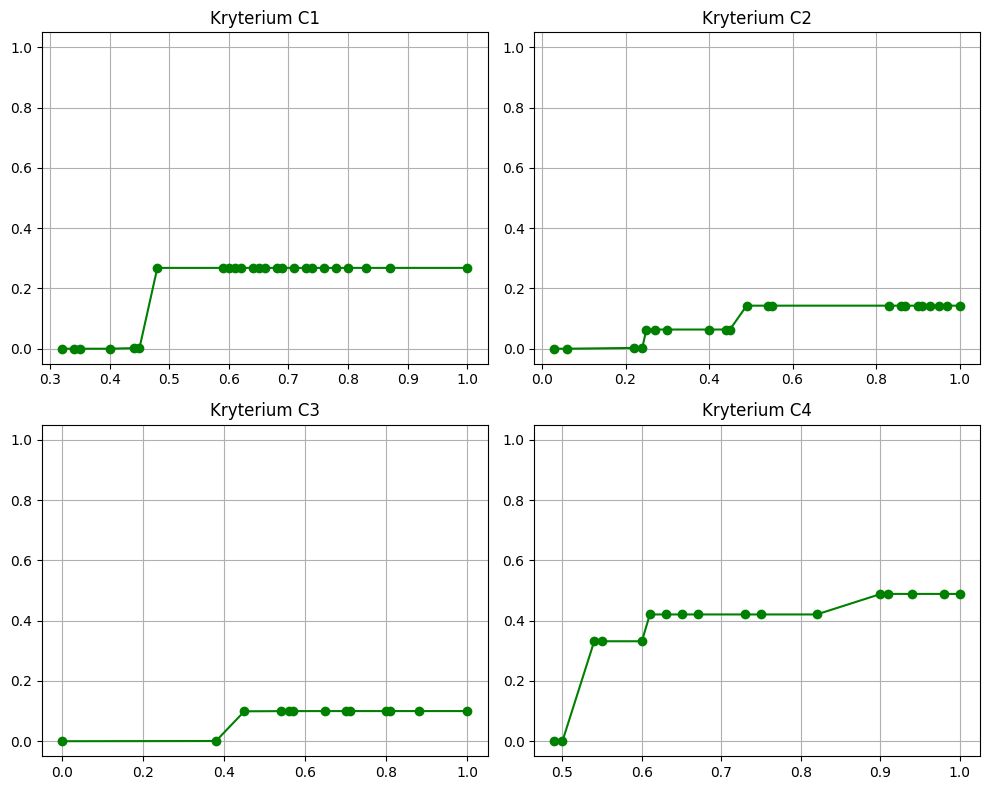

In [9]:
print("Zadanie na 5")

# slownik na przechowywanie sum
u_srednie = {}
for k in kryteria:
    u_srednie[k] = {}
    for w in unikalne_wartosci[k]:
        u_srednie[k][w] = 0.0

udane_proby = 0

for k_cel in kryteria:
    for w_cel in unikalne_wartosci[k_cel]:
        # iterujemy dwa razy: raz min, raz max
        for kierunek in [LpMaximize, LpMinimize]:
            model_rep = LpProblem("rep", kierunek)
            eps_rep = LpVariable("eps_r", lowBound=0)
            
            u_r = {}
            for k in kryteria:
                u_r[k] = {}
                for w in unikalne_wartosci[k]:
                    u_r[k][w] = LpVariable("ur_"+str(k)+"_"+str(w)+"_"+str(kierunek), lowBound=0)
            
            for k in kryteria:
                wart = unikalne_wartosci[k]
                model_rep += u_r[k][wart[0]] == 0
                model_rep += u_r[k][wart[-1]] >= 0.1
                for i in range(len(wart) - 1):
                    model_rep += u_r[k][wart[i]] <= u_r[k][wart[i+1]]
            
            suma_wag_r = []
            for k in kryteria:
                suma_wag_r.append(u_r[k][unikalne_wartosci[k][-1]])
            model_rep += lpSum(suma_wag_r) == 1.0
            
            for lep, gor in preferencje:
                s_lep = [u_r[k][df.loc[lep, k]] for k in kryteria]
                s_gor = [u_r[k][df.loc[gor, k]] for k in kryteria]
                model_rep += lpSum(s_lep) >= lpSum(s_gor) + eps_rep
            
            # blokujemy epsilon na optymalnym poziomie z 3 zadania
            model_rep += eps_rep >= opt_eps - 0.0001
            
            model_rep += u_r[k_cel][w_cel]
            model_rep.solve(PULP_CBC_CMD(msg=0))
            
            if LpStatus[model_rep.status] == 'Optimal':
                for k in kryteria:
                    for w in unikalne_wartosci[k]:
                        u_srednie[k][w] += value(u_r[k][w])
                udane_proby += 1

# wyciagamy srednia dzielac przez ilosc prob
for k in kryteria:
    for w in unikalne_wartosci[k]:
        u_srednie[k][w] = u_srednie[k][w] / udane_proby

wyniki_rep = []
for w in warianty:
    u_glob = 0
    for k in kryteria:
        u_glob += u_srednie[k][df.loc[w, k]]
    wyniki_rep.append([w, u_glob])

df_rep = pd.DataFrame(wyniki_rep, columns=['Wariant', 'Uzytecznosc'])
df_rep = df_rep.sort_values(by='Uzytecznosc', ascending=False).reset_index(drop=True)
df_rep.index = df_rep.index + 1

print("\nRanking usredniony:")
print(df_rep)

# wykresy wygładzone
plt.figure(figsize=(10, 8))
for i in range(len(kryteria)):
    plt.subplot(2, 2, i+1)
    k = kryteria[i]
    x_os = unikalne_wartosci[k]
    y_os = []
    for wart in x_os:
        y_os.append(u_srednie[k][wart])
    plt.plot(x_os, y_os, 'g-o')
    plt.title("Kryterium " + k)
    plt.grid(True)
    plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()